# 📊 Notebook 5 — Final Evaluation & Demo
**Malicious URL Detection | ISCX-URL2016**

This notebook:
- Loads the champion model and runs full test evaluation
- Plots ROC curves (one-vs-rest per class)
- Plots Precision-Recall curves
- Cross-validates the champion
- Compares against `All_BestFirst.csv` and `All_Infogain.csv` (benchmark splits)
- Provides an interactive prediction demo


## 0 · Setup

In [8]:
!pip install -q lightgbm xgboost scikit-learn imbalanced-learn optuna

from google.colab import drive
drive.mount('/content/drive')

import os, json, pickle, warnings
warnings.filterwarnings('ignore')

SAVE_DIR  = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/processed/'
MODEL_DIR = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/modelsv2/'
DATA_DIR  = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/Data/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 · Load Champion Model

In [10]:
import numpy as np
import pandas as pd
import pickle
import json

# 1. Load the file you ACTUALLY saved
with open(MODEL_DIR + 'ml_models.pkl', 'rb') as f:
    model_registry = pickle.load(f)

# 2. Extract the champion model (LightGBM) and the scaler
champion = model_registry['lgbm']
scaler   = model_registry['scaler']
champion_name = 'LightGBM'

# 3. Define your label_map manually (since it wasn't saved in ml_models.pkl)
# Make sure these match the exact order of your LabelEncoder classes!
label_map = {
    0: 'Benign',
    1: 'Defacement',
    2: 'Malware',
    3: 'Phishing',
    4: 'Spam'
}

# 4. Load your top features
try:
    with open(SAVE_DIR + 'top_features.json', 'r') as f:
        top_features = json.load(f)
except FileNotFoundError:
    print("Warning: top_features.json not found. Make sure the path is correct.")

# 5. Verify it loaded correctly
print(f'Champion model : {champion_name}')
print(f'Classes        : {label_map}')
print(f'Model loaded successfully: {champion}')

Champion model : LightGBM
Classes        : {0: 'Benign', 1: 'Defacement', 2: 'Malware', 3: 'Phishing', 4: 'Spam'}
Model loaded successfully: LGBMClassifier(class_weight='balanced', colsample_bytree=0.8, device='gpu',
               learning_rate=0.05, max_depth=10, n_estimators=500, n_jobs=-1,
               num_leaves=63, random_state=42, subsample=0.8, verbose=-1)


## 2 · Load Test Data

In [11]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(SAVE_DIR + 'processed_data.csv')
X  = df.drop(columns=['label'])
y  = df['label']

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_test_sc = scaler.transform(X_test)

n_classes = len(label_map)
print(f'Test set: {X_test_sc.shape}')

Test set: (7342, 40)


## 3 · Full Evaluation

In [12]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred  = champion.predict(X_test_sc)
y_proba = champion.predict_proba(X_test_sc)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

def macro_fpr(y_true, y_pred_arr, n_cls):
    fprs = []
    for c in range(n_cls):
        yt = (np.array(y_true)==c).astype(int)
        yp = (np.array(y_pred_arr)==c).astype(int)
        cm = confusion_matrix(yt, yp)
        tn, fp = cm[0,0], cm[0,1]
        fprs.append(fp/(fp+tn) if (fp+tn)>0 else 0)
    return np.mean(fprs)

fpr = macro_fpr(y_test, y_pred, n_classes)

print(f'\n{"="*52}')
print(f'  🏆 {champion_name}')
print(f'  Accuracy : {acc:.4f}')
print(f'  Macro F1 : {f1:.4f}')
print(f'  Macro FPR: {fpr:.4f}')
print(f'  ROC-AUC  : {auc:.4f}')
print(f'{"="*52}')

print('\nPer-class report:')
print(classification_report(y_test, y_pred,
      target_names=[label_map[i] for i in sorted(label_map)]))


  🏆 LightGBM
  Accuracy : 0.9873
  Macro F1 : 0.9874
  Macro FPR: 0.0032
  ROC-AUC  : 0.9996

Per-class report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00      1586
  Defacement       0.98      0.99      0.99      1556
     Malware       1.00      0.99      0.99      1343
    Phishing       0.97      0.97      0.97      1517
        Spam       0.99      0.98      0.99      1340

    accuracy                           0.99      7342
   macro avg       0.99      0.99      0.99      7342
weighted avg       0.99      0.99      0.99      7342



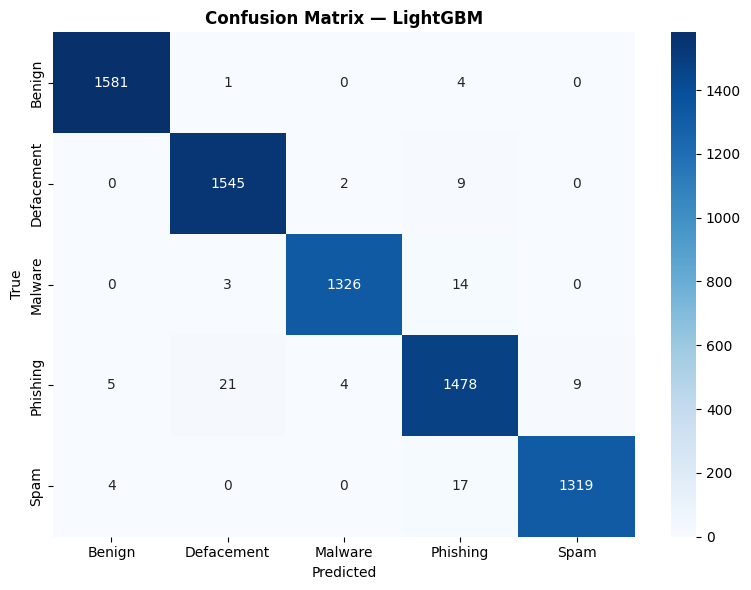

In [13]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
labels = [label_map[i] for i in sorted(label_map)]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title(f'Confusion Matrix — {champion_name}', fontweight='bold', fontsize=12)
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(MODEL_DIR + 'champion_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · ROC Curves (One-vs-Rest per Class)

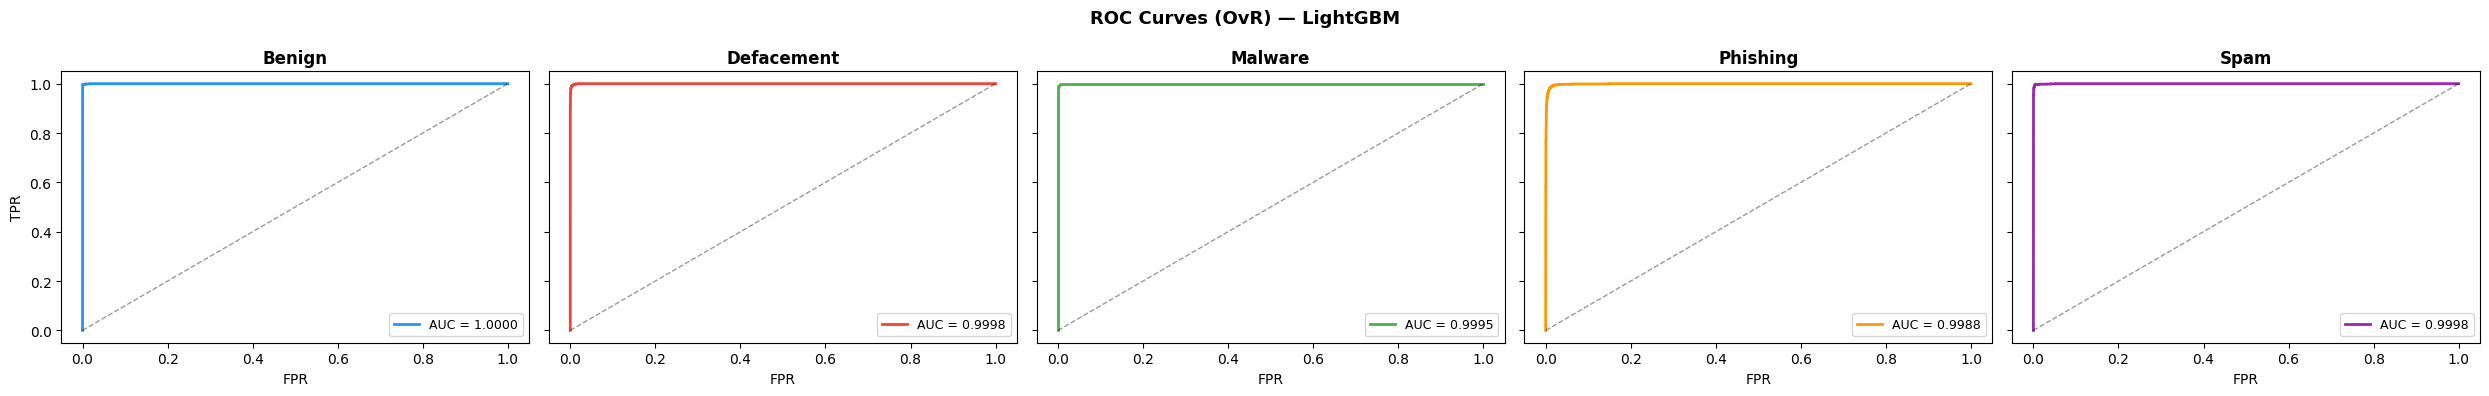

In [14]:
from sklearn.preprocessing import label_binarize

classes = sorted(label_map.keys())
Y_test_bin = label_binarize(y_test, classes=classes)

colors = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0']
fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 4), sharey=True)

for i, (c, color) in enumerate(zip(classes, colors)):
    fpr_c, tpr_c, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    auc_c = roc_auc_score(Y_test_bin[:, i], y_proba[:, i])
    ax = axes[i] if n_classes > 1 else axes
    ax.plot(fpr_c, tpr_c, color=color, lw=2, label=f'AUC = {auc_c:.4f}')
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4)
    ax.set_title(label_map[c], fontweight='bold')
    ax.set_xlabel('FPR'); ax.legend(loc='lower right', fontsize=9)

axes[0].set_ylabel('TPR')
plt.suptitle(f'ROC Curves (OvR) — {champion_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR + 'champion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Precision-Recall Curves

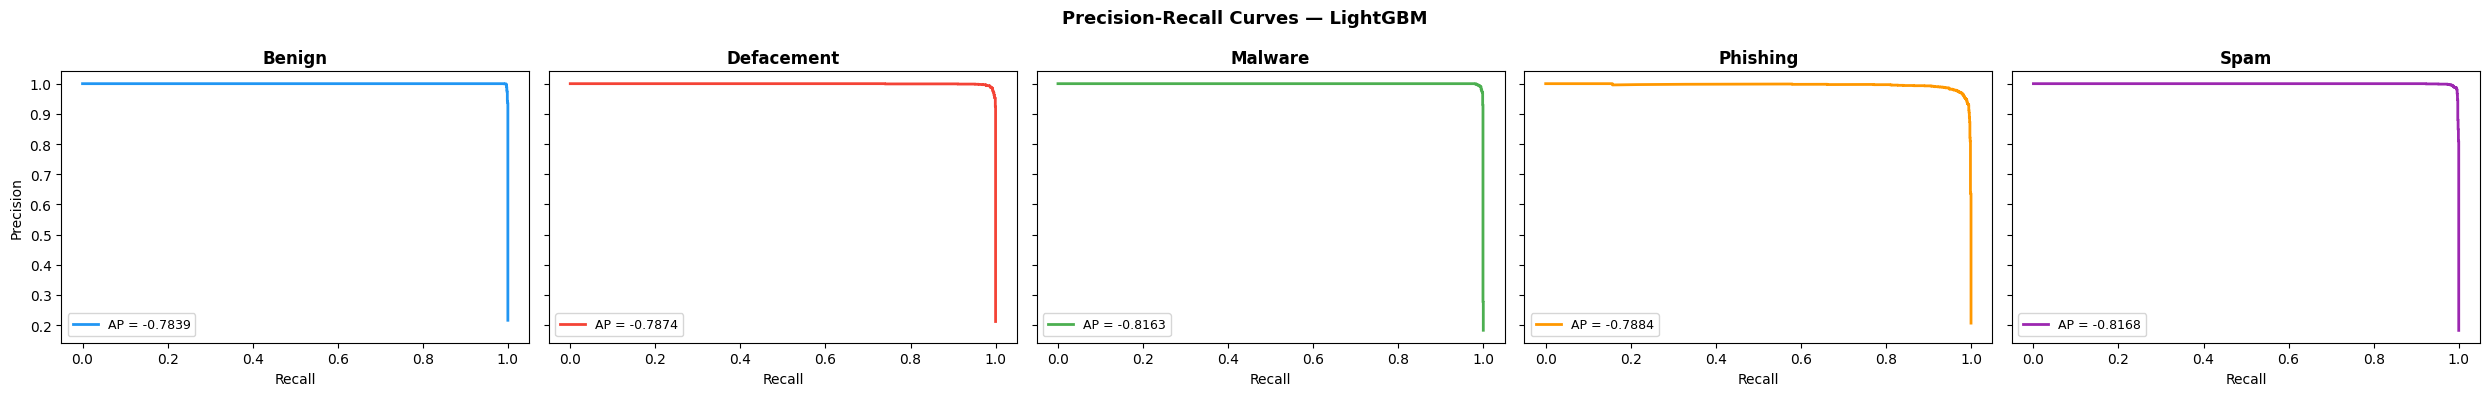

In [15]:
fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 4), sharey=True)

for i, (c, color) in enumerate(zip(classes, colors)):
    prec, rec, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    ap = np.trapz(rec[::-1], prec[::-1])
    ax = axes[i] if n_classes > 1 else axes
    ax.plot(rec, prec, color=color, lw=2, label=f'AP = {ap:.4f}')
    ax.set_title(label_map[c], fontweight='bold')
    ax.set_xlabel('Recall'); ax.legend(loc='lower left', fontsize=9)

axes[0].set_ylabel('Precision')
plt.suptitle(f'Precision-Recall Curves — {champion_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR + 'champion_pr.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Cross-Validation (5-fold)

5-Fold CV Results for LightGBM:
  Accuracy : 0.9818 ± 0.0017
  Macro F1 : 0.9820 ± 0.0017


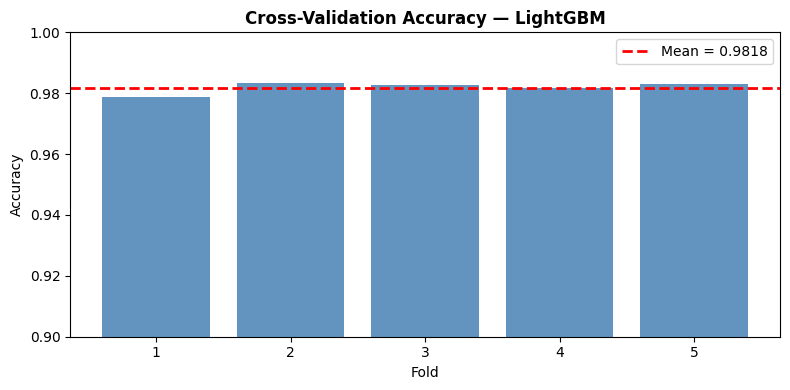

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Cross-validate on raw (pre-SMOTE) scaled data
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler as SS

# Rebuild a pipeable version of the champion for CV
from lightgbm import LGBMClassifier

# Load best params from study (re-read if needed)
try:
    best_params = study.best_params
except NameError:
    best_params = {}  # fallback to defaults

cv_model = Pipeline([
    ('scaler', SS()),
    ('clf', LGBMClassifier(
        **best_params,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
        verbose=-1
    ))
])

cv_results = cross_validate(
    cv_model, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=['accuracy', 'f1_macro'],
    n_jobs=-1
)

print(f'5-Fold CV Results for {champion_name}:')
print(f'  Accuracy : {cv_results["test_accuracy"].mean():.4f} ± {cv_results["test_accuracy"].std():.4f}')
print(f'  Macro F1 : {cv_results["test_f1_macro"].mean():.4f} ± {cv_results["test_f1_macro"].std():.4f}')

# Plot per-fold accuracy
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_results['test_accuracy'], color='steelblue', alpha=0.85)
plt.axhline(cv_results['test_accuracy'].mean(), color='red', lw=2, linestyle='--',
             label=f'Mean = {cv_results["test_accuracy"].mean():.4f}')
plt.xlabel('Fold'); plt.ylabel('Accuracy')
plt.title(f'Cross-Validation Accuracy — {champion_name}', fontweight='bold')
plt.legend()
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.savefig(MODEL_DIR + 'cv_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Benchmark vs BestFirst & Infogain Splits

  BestFirst (8 features): Accuracy = 0.9364
  Infogain (12 features): Accuracy = 0.9725


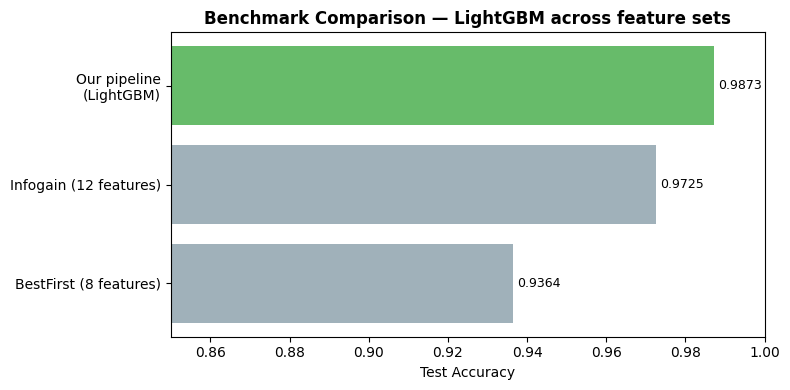

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- MISSING IMPORTS ADDED HERE ---
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier as LGBM_bench
# ----------------------------------

bench_results = {}

for fname, label in [
    ('All_BestFirst.csv', 'BestFirst (8 features)'),
    ('All_Infogain.csv',  'Infogain (12 features)')
]:
    try:
        df_b = pd.read_csv(DATA_DIR + fname)
        # Detect target column
        tgt = 'class' if 'class' in df_b.columns else df_b.columns[-1]

        # Encode
        le_b = LabelEncoder()
        y_b = le_b.fit_transform(df_b[tgt])
        X_b = df_b.drop(columns=[tgt]).replace(-1, np.nan).fillna(0)

        X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
            X_b, y_b, test_size=0.2, stratify=y_b, random_state=42
        )

        # Now StandardScaler will work perfectly!
        sc_b = StandardScaler()
        X_tr_b = sc_b.fit_transform(X_tr_b)
        X_te_b = sc_b.transform(X_te_b)

        m = LGBM_bench(n_estimators=300, class_weight='balanced', n_jobs=-1,
                        random_state=42, verbose=-1)
        m.fit(X_tr_b, y_tr_b)
        acc_b = accuracy_score(y_te_b, m.predict(X_te_b))
        bench_results[label] = acc_b
        print(f'  {label}: Accuracy = {acc_b:.4f}')
    except Exception as e:
        print(f'  {label}: Error — {e}')

# Add our champion (Assuming 'acc' and 'champion_name' are defined earlier in your notebook)
try:
    bench_results[f'Our pipeline\n({champion_name})'] = acc
except NameError:
    print("Note: 'acc' or 'champion_name' not found. Make sure you run your previous cells.")

plt.figure(figsize=(8, 4))
names = list(bench_results.keys())
vals  = list(bench_results.values())
bar_colors = ['#4CAF50' if 'Our' in n else '#90A4AE' for n in names]
plt.barh(names, vals, color=bar_colors, alpha=0.85)
plt.xlabel('Test Accuracy')
plt.title('Benchmark Comparison — LightGBM across feature sets', fontweight='bold')
for i, v in enumerate(vals):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.xlim(0.85, 1.0)
plt.tight_layout()
plt.savefig(MODEL_DIR + 'benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Interactive Prediction Demo

In [22]:
def predict_sample(sample_idx: int = 0):
    """
    Given a row index from the test set, prints the prediction vs. ground truth.
    """
    x = X_test_sc[sample_idx:sample_idx+1]
    true_label  = label_map[int(y_test.iloc[sample_idx])]
    pred_label  = label_map[int(champion.predict(x)[0])]
    proba       = champion.predict_proba(x)[0]

    print(f'\n--- Sample {sample_idx} ---')
    print(f'True class     : {true_label}')
    print(f'Predicted class: {pred_label}  {"✅" if true_label == pred_label else "❌"}')
    print('\nClass probabilities:')
    for c, p in sorted(zip(label_map.values(), proba), key=lambda x: -x[1]):
        bar = '█' * int(p * 30)
        print(f'  {c:15s}  {bar:<30s} {p:.4f}')

# Try a few samples
for idx in [0, 10, 100, 500, 1000]:
    predict_sample(idx)


--- Sample 0 ---
True class     : Defacement
Predicted class: Defacement  ✅

Class probabilities:
  Defacement       █████████████████████████████  1.0000
  Phishing                                        0.0000
  Malware                                         0.0000
  Benign                                          0.0000
  Spam                                            0.0000

--- Sample 10 ---
True class     : Spam
Predicted class: Spam  ✅

Class probabilities:
  Spam             █████████████████████████████  1.0000
  Phishing                                        0.0000
  Benign                                          0.0000
  Defacement                                      0.0000
  Malware                                         0.0000

--- Sample 100 ---
True class     : Spam
Predicted class: Spam  ✅

Class probabilities:
  Spam             █████████████████████████████  1.0000
  Phishing                                        0.0000
  Malware                               

In [23]:
# ── Interactive widget (Colab) ──
from ipywidgets import interact, IntSlider

max_idx = len(y_test) - 1

@interact(sample_index=IntSlider(min=0, max=max_idx, step=1, value=0,
                                  description='Sample index:'))
def interactive_predict(sample_index=0):
    predict_sample(sample_index)

interactive(children=(IntSlider(value=0, description='Sample index:', max=7341), Output()), _dom_classes=('wid…

## 9 · Final Summary Table

In [24]:
# Load and print final leaderboard
leaderboard = pd.read_csv(MODEL_DIR + 'final_leaderboard.csv', index_col=0)

def highlight_best(s):
    is_best = s == (s.max() if s.name != 'Macro FPR' else s.min())
    return ['background-color: #c8e6c9; font-weight: bold' if v else '' for v in is_best]

styled = leaderboard.style.apply(highlight_best).format('{:.4f}')
display(styled)

print(f'\n✅ Champion: {champion_name}')
print(f'   Accuracy: {acc:.4f} | FPR: {fpr:.4f} | AUC: {auc:.4f}')

,Accuracy,Macro F1,Macro FPR,ROC-AUC
LightGBM,0.9873,0.9874,0.0032,0.9996
LightGBM (Optuna-tuned),0.9873,0.9874,0.0032,0.9996
Stacking Ensemble (RF+XGB+LGBM → LR),0.9872,0.9873,0.0032,0.9994
Weighted Soft Voting (RF+XGB+LGBM),0.9867,0.9867,0.0034,0.9995
XGBoost,0.9837,0.9838,0.0041,0.9995
Binary Specialist Meta-Ensemble,0.9807,0.9810,0.0049,0.9985
Random Forest,0.9752,0.9755,0.0062,0.9990
Decision Tree,0.9516,0.9517,0.0121,0.9758
Logistic Regression,0.8001,0.7991,0.0501,0.9591
SVM (Linear),0.7700,0.7655,0.0576,0.9478



✅ Champion: LightGBM
   Accuracy: 0.9873 | FPR: 0.0032 | AUC: 0.9996
